# 1. Import libraries

In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 11.8 MB/s eta 0:00:00


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix , classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')
import random
import tensorflow as tf
import os
from tensorflow.keras import layers, Model, optimizers, regularizers
import keras_tuner as kt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import kagglehub
import os

In [ ]:
# Set seed for reproducibility
SEED = 14

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# 2. Load and pre-process the dataset

In [ ]:

# 1. Download the latest version of the dataset directly from Kaggle
raw_path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", raw_path)

# 2. Set the dataset directory to the specific folder inside the download
# The dataset structure usually includes 'seg_train/seg_train'
dataset_dir = os.path.join(raw_path, "seg_train", "seg_train")

# IF YOU USE YOUR OWN COMPUTER:

# LIST THE CLASSES THAT EXIST WITHIN THIS DATASET:
CLASS_LABELS  = ['buildings', 'forest','glacier','mountain','sea','street'] # creates a list of the 6 classes in this dataset (the dataset contains images of 6 types of landscapes)

In [ ]:
# LOAD AND PREPROCESS THE DATA:

# set size of images (in pixels) after resizing
IMG_HEIGHT = 42
IMG_WIDTH = 42

# set batch size
BATCH_SIZE = 128

# set relative sizes of the test and val set
TEST_SIZE = 0.2   # 20% of all x images will be used for testing the model
VAL_SIZE = 0.2    # of the remaining images, 20% will be used for validation and 80% for training

# function for adding noise to the images
def add_noise(img):
    std_coeff = 20 * np.random.random()
    noise = np.random.normal(0, std_coeff, img.shape)
    img += noise
    img = np.clip(img, 0., 255.)
    return img

# build dataframe with file paths and labels
all_files = []
all_labels = []

for class_name in sorted(os.listdir(dataset_dir)):
    class_path = os.path.join(dataset_dir, class_name)
    if os.path.isdir(class_path):
        for fname in os.listdir(class_path):
            fpath = os.path.join(class_path, fname)
            all_files.append(fpath)
            all_labels.append(class_name)

df = pd.DataFrame({"filename": all_files, "class": all_labels})

# split the data into train / val / test
trainval_df, test_df = train_test_split(df, test_size=TEST_SIZE, stratify=df["class"], random_state=31) # split all data into trainval + test
train_df, val_df   = train_test_split(trainval_df, test_size=VAL_SIZE, stratify=trainval_df["class"], random_state=31)  # split trainval data into train + val

# define generators
train_datagen = ImageDataGenerator(rescale=1./255, preprocessing_function=add_noise) # note: noise is only added to the train samples.
val_test_datagen = ImageDataGenerator(rescale=1./255)

# apply generators
train_data = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=7
)

val_data = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=7
)

test_data = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Data loading completed successfully.")
print(f"Number of training samples: {train_data.samples}")
print(f"Number of validation samples: {val_data.samples}")
print(f"Number of test samples: {test_data.samples}")
print(f"Class names: {train_data.class_indices}")

Found 8981 validated image filenames belonging to 6 classes.
Found 2246 validated image filenames belonging to 6 classes.
Found 2807 validated image filenames belonging to 6 classes.
Data loading completed successfully.
Number of training samples: 8981
Number of validation samples: 2246
Number of test samples: 2807
Class names: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


# 3. Visualise data and plot data distribution

In [ ]:
#If you want to visualize the images in their real sizes, you can create a new dataloader and remove the resizing argument as shown below.
#If you want to visualize the images in their resized sizes, you can use the datalaoder as shown in the previous cells.

Found 15 validated image filenames belonging to 6 classes.


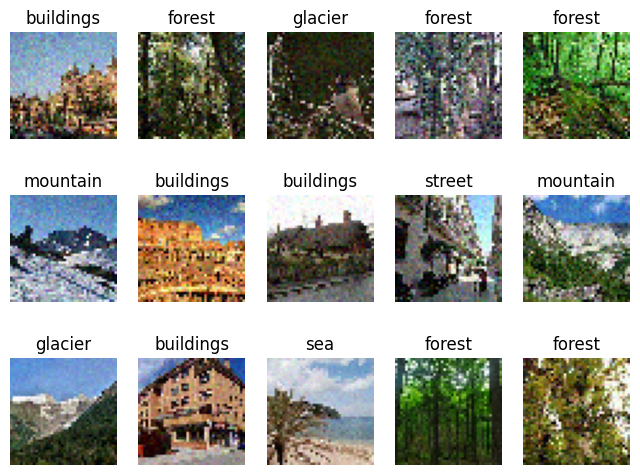

In [ ]:
# 1. Visualize 15 samples from the dataset
import random

# randomly sample 15 rows from the dataframe
sample_df = df.sample(n=15, random_state=123)

# generate data from sample dataframe
sample = train_datagen.flow_from_dataframe(
    sample_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="sparse",
    shuffle=True,
    seed=7
)

# get the images and labels of the sample
sample_images, sample_labels = next(sample)
# get class labels
classes = sample.class_indices
index_to_class = {}
for class_name, index in classes.items():
    index_to_class[index] = class_name
# set the figure size
plt.figure(figsize=(8, 6))
for i in range(0,15):
	# define subplot
  plt.subplot(3,5,i+1)
	# plot raw pixel data
  plt.imshow(sample_images[i])
  # plot the label on top of each image
  plt.title(index_to_class[sample_labels[i]])
  # turn off the axes
  plt.axis("off")
# show the figure
plt.show()

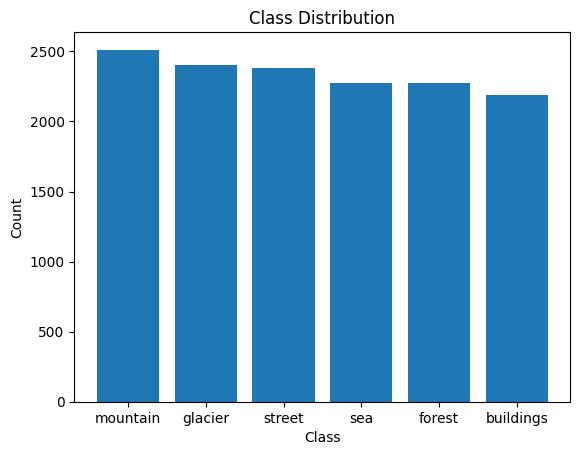

In [ ]:
# 2. Visualize class distribution
class_counts = df["class"].value_counts()
plt.bar(class_counts.index, class_counts.values)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# 4. Model Design and Train and Evaluation functions

In [ ]:
def baseline_model():
  #Inputs
  inputs = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

  #Block 1
  x = layers.Conv2D(16, (3,3), padding='same', activation ='relu')(inputs)
  x = layers.MaxPooling2D((2,2))(x)

  #Block 2
  x = layers.Conv2D(32, (3,3),padding='same',activation ='relu')(x)
  x = layers.MaxPooling2D((2,2))(x)

  #Block 3
  x = layers.Conv2D(48, (3, 3),padding='same', activation='relu')(x)
  x = layers.MaxPooling2D((2, 2))(x)

  x = layers.Flatten()(x)
  x = layers.Dense(128, activation='relu')(x)
  outputs = layers.Dense(6, activation='softmax')(x)

  # Create final model
  model = Model(inputs=inputs, outputs=outputs)

  #model.summary()


  model.compile(
      optimizer='adam',
      loss='categorical_crossentropy',
      metrics=['accuracy']
  )
  return model

In [ ]:
def build_improved_model():
    inputs = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

    # Block 1
    x = layers.Conv2D(32, (3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # block 2
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 3
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Flatten()(x)

    # Dense layer
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(6, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# 5. Model training

### 5.1 Baseline Model

In [ ]:
# Train model with 15 epochs
model = baseline_model()
model.summary()
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 42, 42, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 42, 42, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 21, 21, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 48)     │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       153,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,462 (677.59 KB)

 Trainable params: 173,462 (677.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 20s 212ms/step - accuracy: 0.3949 - loss: 1.4875 - val_accuracy: 0.5904 - val_loss: 1.0862
Epoch 2/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 142ms/step - accuracy: 0.6019 - loss: 1.0295 - val_accuracy: 0.6331 - val_loss: 1.0124
Epoch 3/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 153ms/step - accuracy: 0.6451 - loss: 0.9400 - val_accuracy: 0.6719 - val_loss: 0.8890
Epoch 4/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 152ms/step - accuracy: 0.6938 - loss: 0.8300 - val_accuracy: 0.7128 - val_loss: 0.8197
Epoch 5/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 151ms/step - accuracy: 0.7212 - loss: 0.7450 - val_accuracy: 0.7177 - val_loss: 0.7859
Epoch 6/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step - accuracy: 0.7332 - loss: 0.7206 - val_accuracy: 0.7378 - val_loss: 0.7308
Epoch 7/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 154ms/step - accuracy: 0.7524 - loss: 0.6657 - val_accuracy: 0.7168 - val_loss: 0.7568
Epoch 8/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 142ms/step - accuracy: 0.7598 - loss: 0.6665 - val_accu

###5.2 Hyperparameter Tuning

In [ ]:
# Train improved model
from tensorflow.keras.callbacks import EarlyStopping

improved_model = build_improved_model()
improved_model.summary()

early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

history_improved = improved_model.fit(train_data,epochs=20, validation_data=val_data,callbacks=[early_stop])

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 42, 42, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 42, 42, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 42, 42, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 42, 42, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 21, 21, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 21, 21, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 915,142 (3.49 MB)

 Trainable params: 914,694 (3.49 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 23s 216ms/step - accuracy: 0.4029 - loss: 2.4663 - val_accuracy: 0.1621 - val_loss: 2.2361
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 146ms/step - accuracy: 0.6274 - loss: 0.9772 - val_accuracy: 0.1621 - val_loss: 2.8628
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 128ms/step - accuracy: 0.6988 - loss: 0.8033 - val_accuracy: 0.2208 - val_loss: 2.4629
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 145ms/step - accuracy: 0.7234 - loss: 0.7492 - val_accuracy: 0.4118 - val_loss: 1.8819
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 147ms/step - accuracy: 0.7606 - loss: 0.6605 - val_accuracy: 0.6870 - val_loss: 0.8456
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 0.7626 - loss: 0.6613 - val_accuracy: 0.7217 - val_loss: 0.8129
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step - accuracy: 0.7844 - loss: 0.6006 - val_accuracy: 0.6282 - val_loss: 1.0021
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 146ms/step - accuracy: 0.7989 - loss: 0.5586 - val_accura

In [ ]:
# !rm -rf tuning_dir

In [ ]:
# Hyperparameter tuning with Keras Tuner
def build_tuned_improved_model(hp):
    inputs = layers.Input(shape=(42, 42, 3))

    # Block 1: tune initial filters
    hp_filters_1 = hp.Int('filters_1', min_value=32, max_value=64, step=32)
    x = layers.Conv2D(hp_filters_1, (3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 2
    hp_filters_2 = hp.Int('filters_2', min_value=64, max_value=128, step=64)
    x = layers.Conv2D(hp_filters_2, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 3
    hp_filters_3 = hp.Choice('filters_3', values=[128, 256])
    x = layers.Conv2D(hp_filters_3, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Flatten()(x)

    # Dense Layer: tune dropout
    hp_units = hp.Int('dense_units', min_value=128, max_value=512, step=128)
    x = layers.Dense(hp_units, activation='relu')(x)
    hp_dropout = hp.Float('dropout', min_value=0.3, max_value=0.5, step=0.1)
    x = layers.Dropout(hp_dropout)(x)

    outputs = layers.Dense(6, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)

    # Tuning the learning rate
    hp_lr = hp.Choice('learning_rate', values=[0.001, 0.0005, 0.0001])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=hp_lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner = kt.BayesianOptimization(
    build_tuned_improved_model,
    objective='val_accuracy',
    max_trials=10,
    directory='tuning_dir_v2',
    project_name='tune_improved_model'
)
#early stopping
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5)

tuner.search(train_data, epochs=15, validation_data=val_data, callbacks=[stop_early])

Trial 10 Complete [00h 02m 43s]
val_accuracy: 0.754229724407196

Best val_accuracy So Far: 0.8183436989784241
Total elapsed time: 00h 28m 56s


In [ ]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
tuned_improved_model = tuner.hypermodel.build(best_hps)

# Tuned improved model (lower performance than improved_model => I will use improved_model instead of this)
tuned_improved_history = tuned_improved_model.fit(
    train_data,
    epochs=20,
    validation_data=val_data,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)]
)

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 20s 203ms/step - accuracy: 0.4116 - loss: 3.0188 - val_accuracy: 0.1621 - val_loss: 2.1377
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 148ms/step - accuracy: 0.6160 - loss: 1.0047 - val_accuracy: 0.1621 - val_loss: 2.8796
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 149ms/step - accuracy: 0.6784 - loss: 0.8704 - val_accuracy: 0.1625 - val_loss: 2.9317
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - accuracy: 0.7170 - loss: 0.7590 - val_accuracy: 0.1714 - val_loss: 2.9426
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 148ms/step - accuracy: 0.7336 - loss: 0.7073 - val_accuracy: 0.4853 - val_loss: 1.2441
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 152ms/step - accuracy: 0.7540 - loss: 0.6710 - val_accuracy: 0.7026 - val_loss: 0.8194
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 153ms/step - accuracy: 0.7729 - loss: 0.6308 - val_accuracy: 0.6728 - val_loss: 0.8452
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 142ms/step - accuracy: 0.7948 - loss: 0.5817 - val_accur

### 5.3 Transfer Learning Model

In [ ]:
from tensorflow.keras.applications import DenseNet121

densenet_model = DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# freeze all convolutional layers
for layer in densenet_model.layers:
  layer.trainable = False

# add fully connected layers
gap = layers.GlobalAveragePooling2D()(densenet_model.output)
dense1 = layers.Dense(128)(gap)
drop1 = layers.Dropout(0.5)(dense1)
output = layers.Dense(6, activation='softmax')(drop1)

densenet_model = Model(inputs=densenet_model.inputs, outputs=output)

# compile model
densenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#train model
history_tl = densenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.4962 - loss: 1.5688 - val_accuracy: 0.7253 - val_loss: 0.7988
Epoch 2/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 217ms/step - accuracy: 0.6994 - loss: 0.8437 - val_accuracy: 0.7431 - val_loss: 0.7589
Epoch 3/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 16s 229ms/step - accuracy: 0.7198 - loss: 0.7744 - val_accuracy: 0.7444 - val_loss: 0.7456
Epoch 4/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 22s 305ms/step - accuracy: 0.7392 - loss: 0.7110 - val_accuracy: 0.7627 - val_loss: 0.6868
Epoch 5/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 32s 169ms/step - accuracy: 0.7481 - loss: 0.6776 - val_accuracy: 0.7640 - val_loss: 0.6864
Epoch 6/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 13s 182ms/step - accuracy: 0.7557 - loss: 0.6396 - val_accuracy: 0.7573 - val_loss: 0.6893
Epoch 7/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 200ms/step - accuracy: 0.7664 - loss: 0.6324 - val_accuracy: 0.7618 - val_loss: 0.6915
Epoch 8/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 201ms/

# 6. Model evaluation

### 6.1 Baseline Model

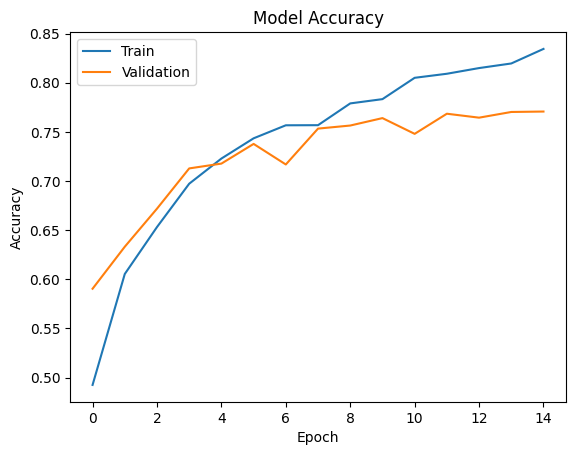

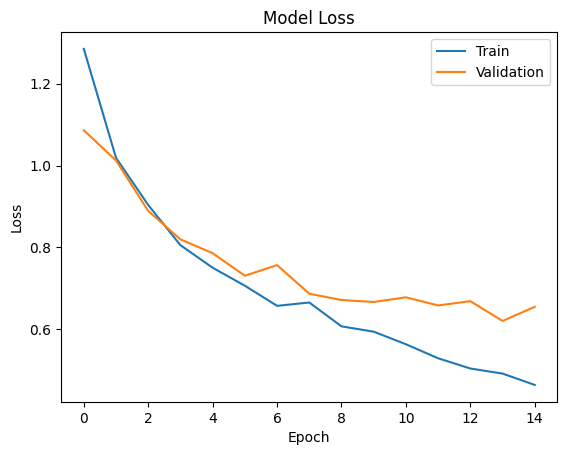

18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 176ms/step


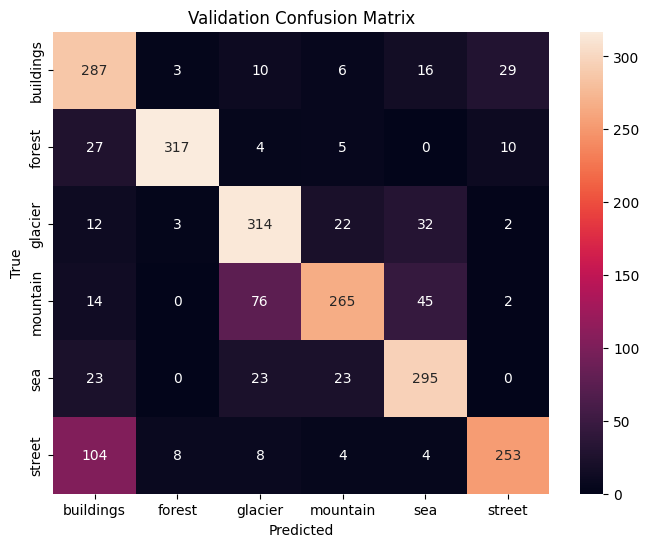

Validation Accuracy: 0.7707034728406055
              precision    recall  f1-score   support

   buildings       0.61      0.82      0.70       351
      forest       0.96      0.87      0.91       363
     glacier       0.72      0.82      0.77       385
    mountain       0.82      0.66      0.73       402
         sea       0.75      0.81      0.78       364
      street       0.85      0.66      0.75       381

    accuracy                           0.77      2246
   macro avg       0.79      0.77      0.77      2246
weighted avg       0.79      0.77      0.77      2246



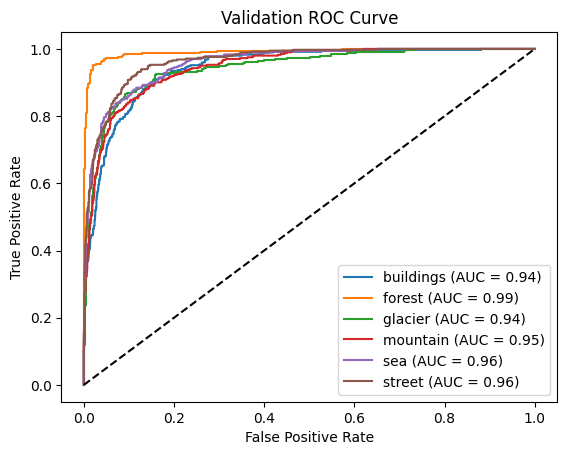

In [ ]:
# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

#validation set predictions
val_data.reset()
val_data.shuffle = False
val_data.index_array = None

val_probs = model.predict(val_data)
val_preds = np.argmax(val_probs, axis=1)
val_true = val_data.classes

#confusion matrix
cm_val = confusion_matrix(val_true, val_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm_val, annot=True, fmt='d',
            xticklabels=CLASS_LABELS,
            yticklabels=CLASS_LABELS)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Validation Confusion Matrix")
plt.show()


print("Validation Accuracy:",
      accuracy_score(val_true, val_preds))

print(classification_report(val_true,
                            val_preds,
                            target_names=CLASS_LABELS))

# Binarize labels
val_true_bin = label_binarize(val_true, classes=range(6))

plt.figure()

for i in range(6):
    fpr, tpr, _ = roc_curve(val_true_bin[:, i], val_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{CLASS_LABELS[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curve")
plt.legend()
plt.show()



22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step


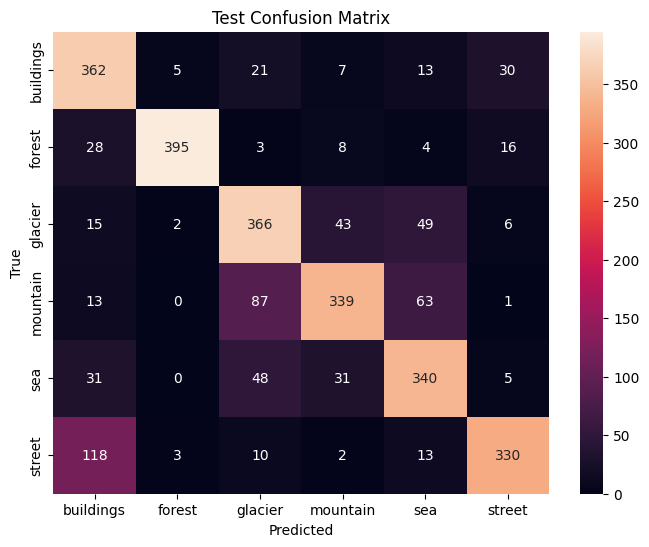

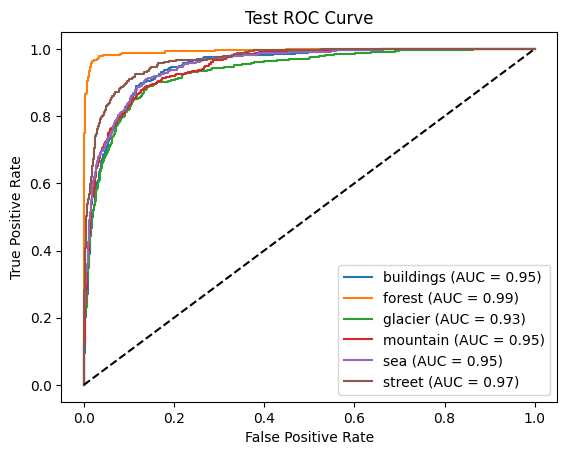

Test Accuracy: 0.7595297470609191
              precision    recall  f1-score   support

   buildings       0.64      0.83      0.72       438
      forest       0.98      0.87      0.92       454
     glacier       0.68      0.76      0.72       481
    mountain       0.79      0.67      0.73       503
         sea       0.71      0.75      0.73       455
      street       0.85      0.69      0.76       476

    accuracy                           0.76      2807
   macro avg       0.77      0.76      0.76      2807
weighted avg       0.77      0.76      0.76      2807



In [ ]:
#repeating with test data

test_data.reset()

test_probs = model.predict(test_data)
test_preds = np.argmax(test_probs, axis=1)
test_true = test_data.classes

cm_test = confusion_matrix(test_true, test_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm_test, annot=True, fmt='d',
            xticklabels=CLASS_LABELS,
            yticklabels=CLASS_LABELS)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.show()



test_true_bin = label_binarize(test_true, classes=range(6))

plt.figure()

for i in range(6):
    fpr, tpr, _ = roc_curve(test_true_bin[:, i], test_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr,
             label=f"{CLASS_LABELS[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test ROC Curve")
plt.legend()
plt.show()

#accuracy
print("Test Accuracy:",
      accuracy_score(test_true, test_preds))

print(classification_report(test_true,
                            test_preds,
                            target_names=CLASS_LABELS))

### 6.2 Improved Model

In [ ]:
val_data.reset()
val_data.shuffle = False
val_data.index_array = None

val_probs_imp = improved_model.predict(val_data)
val_preds_imp = np.argmax(val_probs_imp, axis=1)
val_true = val_data.classes
print(" Improved Model - Validation Set Performance:")
print(classification_report(val_true, val_preds_imp, target_names=CLASS_LABELS))

18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step
 Improved Model - Validation Set Performance:
              precision    recall  f1-score   support

   buildings       0.75      0.78      0.77       351
      forest       0.98      0.90      0.94       363
     glacier       0.83      0.75      0.79       385
    mountain       0.79      0.79      0.79       402
         sea       0.81      0.83      0.82       364
      street       0.78      0.86      0.82       381

    accuracy                           0.82      2246
   macro avg       0.82      0.82      0.82      2246
weighted avg       0.82      0.82      0.82      2246



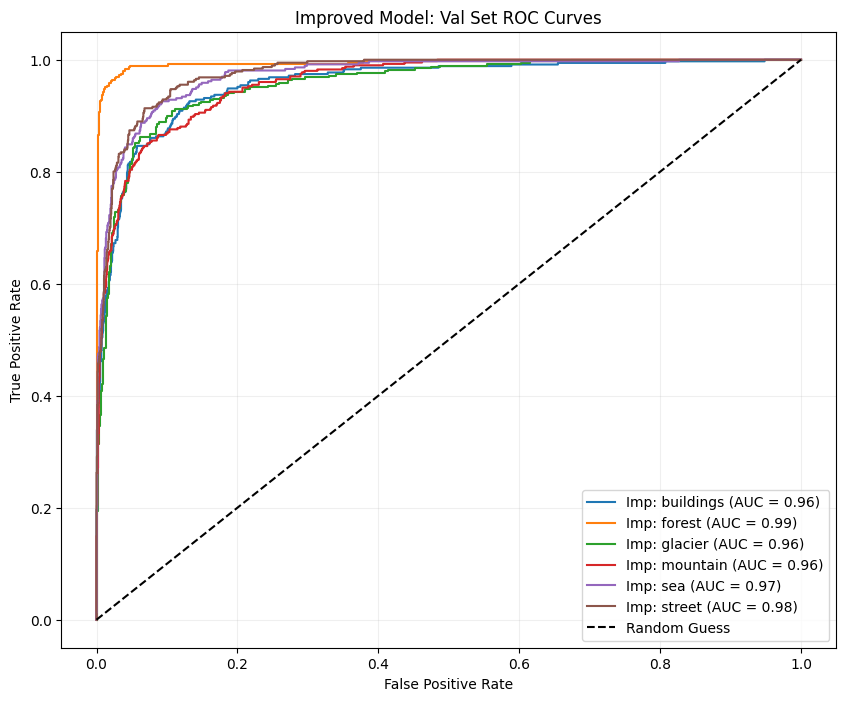

In [ ]:
y_val_bin = label_binarize(val_true, classes=range(6))

plt.figure(figsize=(10, 8))

for i in range(6):
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], val_probs_imp[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Imp: {CLASS_LABELS[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Improved Model: Val Set ROC Curves')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.2)
plt.show()

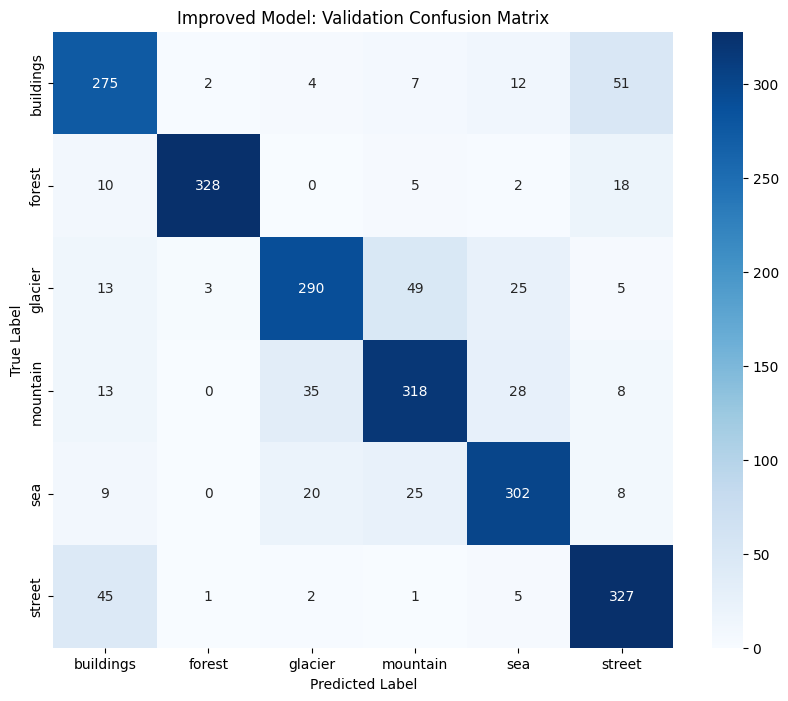

In [ ]:
val_cm_imp = confusion_matrix(val_true, val_preds_imp)

plt.figure(figsize=(10, 8))
sns.heatmap(val_cm_imp, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS)
plt.title('Improved Model: Validation Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
test_data.reset()

test_probs_imp = improved_model.predict(test_data)
test_preds_imp = np.argmax(test_probs_imp, axis=1)
test_true_test = test_data.classes

print(" Improved Model - Test Set Performance:")
print(accuracy_score(test_true_test, test_preds_imp))
print(classification_report(test_true_test, test_preds_imp, target_names=CLASS_LABELS))

22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 173ms/step
 Improved Model - Test Set Performance:
0.8129675810473815
              precision    recall  f1-score   support

   buildings       0.78      0.79      0.79       438
      forest       0.98      0.87      0.92       454
     glacier       0.81      0.71      0.76       481
    mountain       0.76      0.81      0.78       503
         sea       0.80      0.82      0.81       455
      street       0.78      0.88      0.83       476

    accuracy                           0.81      2807
   macro avg       0.82      0.81      0.81      2807
weighted avg       0.82      0.81      0.81      2807



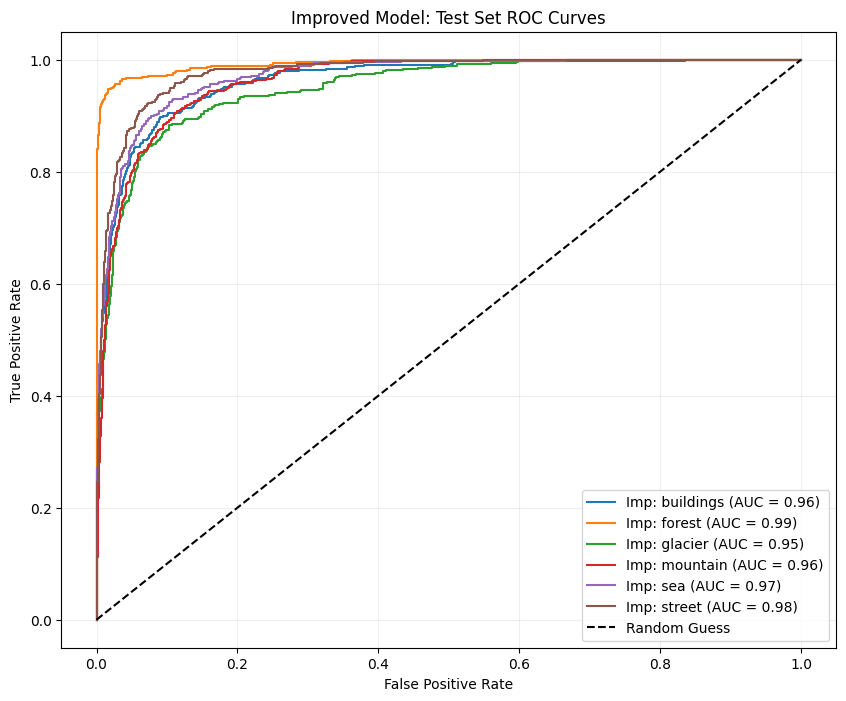

In [ ]:
y_test_bin = label_binarize(test_true_test, classes=range(6))

plt.figure(figsize=(10, 8))

for i in range(6):
    # Calculate ROC for Improved Model
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_probs_imp[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Imp: {CLASS_LABELS[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Improved Model: Test Set ROC Curves')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.2)
plt.show()

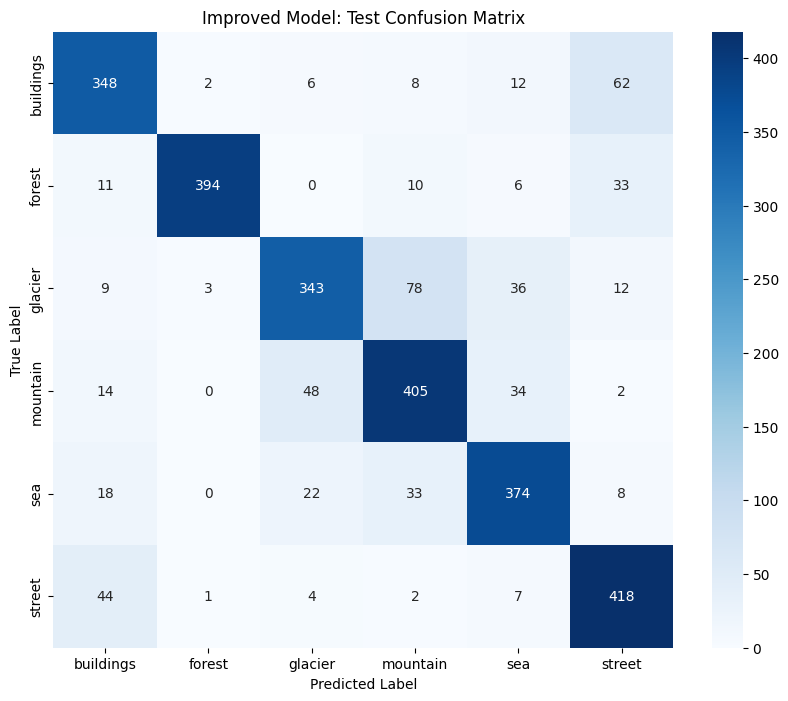

In [ ]:
cm_imp = confusion_matrix(test_true_test, test_preds_imp)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_imp, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS)
plt.title('Improved Model: Test Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

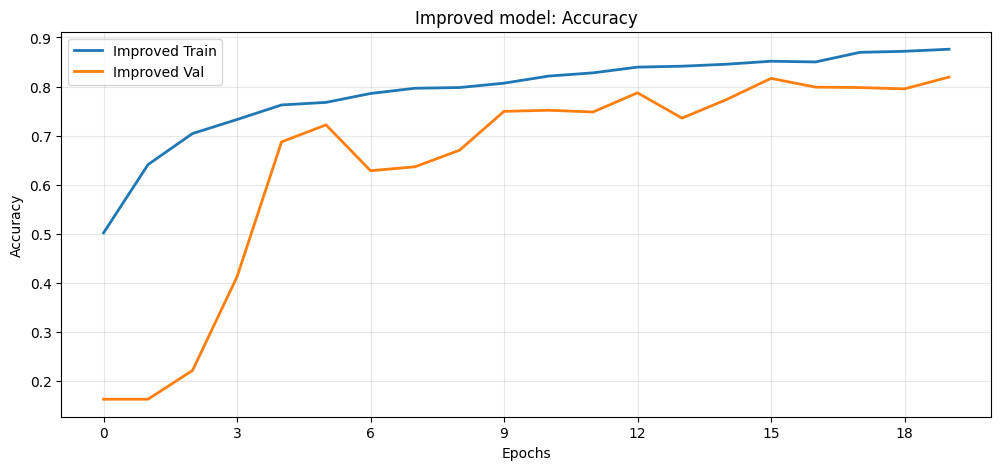

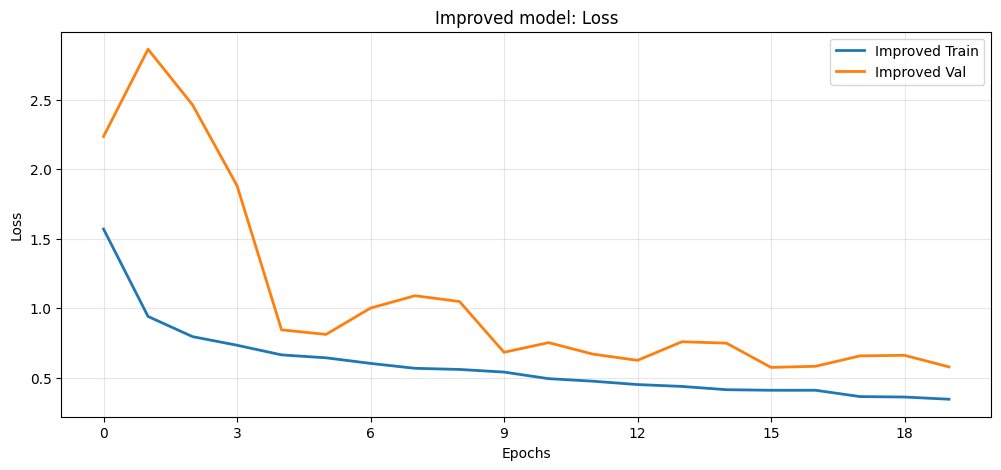

In [ ]:
from matplotlib.ticker import MaxNLocator
metric = ["accuracy","loss"]
for m in metric:
  plt.figure(figsize=(12, 5))
  # Improved
  plt.plot(history_improved.history[m], label='Improved Train', linewidth=2)
  plt.plot(history_improved.history[f'val_{m}'], label='Improved Val', linewidth=2)
  plt.title(f'Improved model: {m.capitalize()}')
  plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
  plt.xlabel('Epochs')
  plt.ylabel(m.capitalize())
  plt.legend()
  plt.grid(True, alpha=0.3)
  plt.show()

### 6.3 Transfer Learning

22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 735ms/step - accuracy: 0.7654 - loss: 0.6738
Test Accuracy: 0.7716423273086548
22/22 ━━━━━━━━━━━━━━━━━━━━ 35s 992ms/step


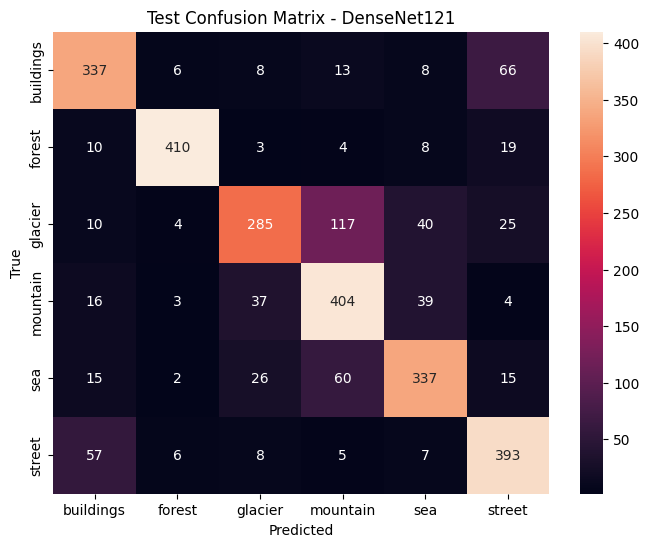

              precision    recall  f1-score   support

   buildings       0.76      0.77      0.76       438
      forest       0.95      0.90      0.93       454
     glacier       0.78      0.59      0.67       481
    mountain       0.67      0.80      0.73       503
         sea       0.77      0.74      0.75       455
      street       0.75      0.83      0.79       476

    accuracy                           0.77      2807
   macro avg       0.78      0.77      0.77      2807
weighted avg       0.78      0.77      0.77      2807



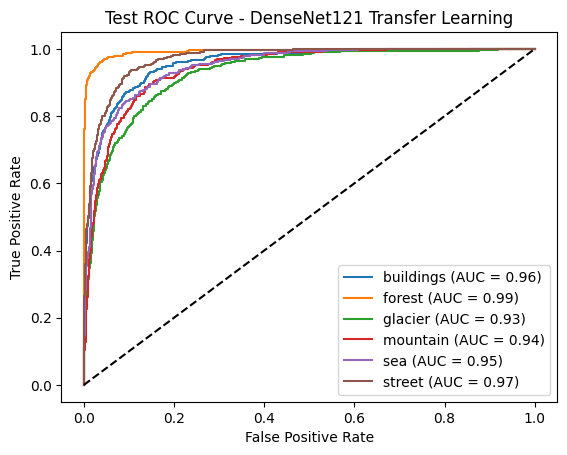

In [ ]:
test_loss, test_acc = densenet_model.evaluate(test_data)
print('Test Accuracy:', test_acc)

# confusion matrix
test_data.reset()

test_probs = densenet_model.predict(test_data)
test_preds = np.argmax(test_probs, axis=1)
test_true = test_data.classes

cm = confusion_matrix(test_true, test_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=CLASS_LABELS,
            yticklabels=CLASS_LABELS)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Test Confusion Matrix - DenseNet121')
plt.show()

print(classification_report(test_true, test_preds,
                            target_names=CLASS_LABELS))

#ROC
test_true_bin = label_binarize(test_true, classes=range(6))

plt.figure()

for i in range(6):
  fpr, tpr, _ = roc_curve(test_true_bin[:, i], test_probs[:, i])
  roc_auc = auc(fpr, tpr)
  plt.plot(fpr, tpr, label=f"{CLASS_LABELS[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Test ROC Curve - DenseNet121 Transfer Learning')
plt.legend()
plt.show()

### All Model Performance Comparison

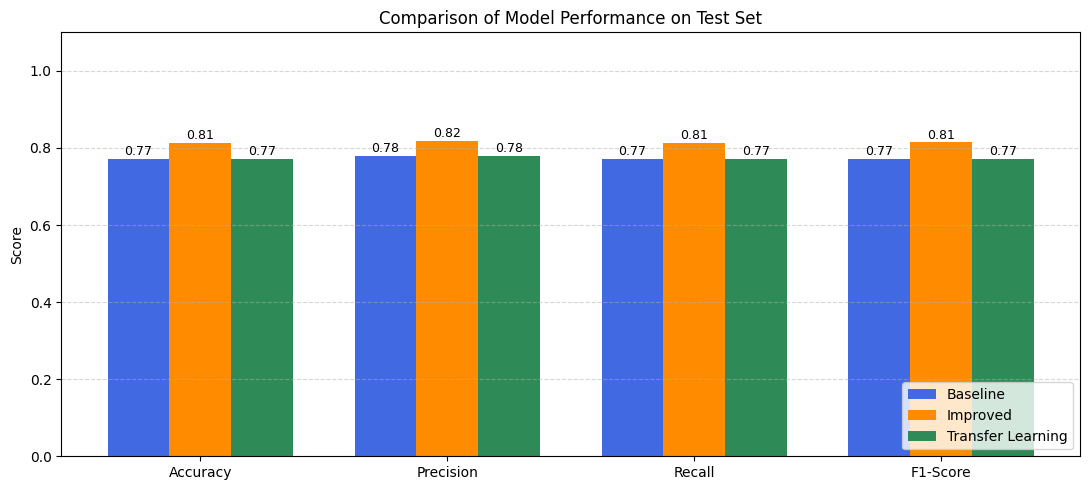

In [ ]:
# Metrics
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

acc_base = accuracy_score(test_true, test_preds)
p_base, r_base, f1_base, _ = precision_recall_fscore_support(test_true, test_preds, average='macro')

acc_imp = accuracy_score(test_true_test, test_preds_imp)
p_imp, r_imp, f1_imp, _ = precision_recall_fscore_support(test_true_test, test_preds_imp, average='macro')

acc_tl = accuracy_score(test_true, test_preds)
p_tl, r_tl, f1_tl, _ = precision_recall_fscore_support(test_true, test_preds, average='macro')

labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_vals = [acc_base, p_base, r_base, f1_base]
improved_vals = [acc_imp, p_imp, r_imp, f1_imp]
tl_vals = [acc_tl, p_tl, r_tl, f1_tl]

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(11, 5))
plt.bar(x - width, baseline_vals, width, label='Baseline', color='royalblue')
plt.bar(x, improved_vals, width, label='Improved', color='darkorange')
plt.bar(x + width, tl_vals, width, label='Transfer Learning', color='seagreen')
plt.title('Comparison of Model Performance on Test Set')
plt.xticks(x, labels)
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add value to the bar
for i in range(len(labels)):
    plt.text(i - width, baseline_vals[i] + 0.01, f'{baseline_vals[i]:.2f}', ha='center', fontsize=9)
    plt.text(i, improved_vals[i] + 0.01, f'{improved_vals[i]:.2f}', ha='center', fontsize=9)
    plt.text(i + width, tl_vals[i] + 0.01, f'{tl_vals[i]:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

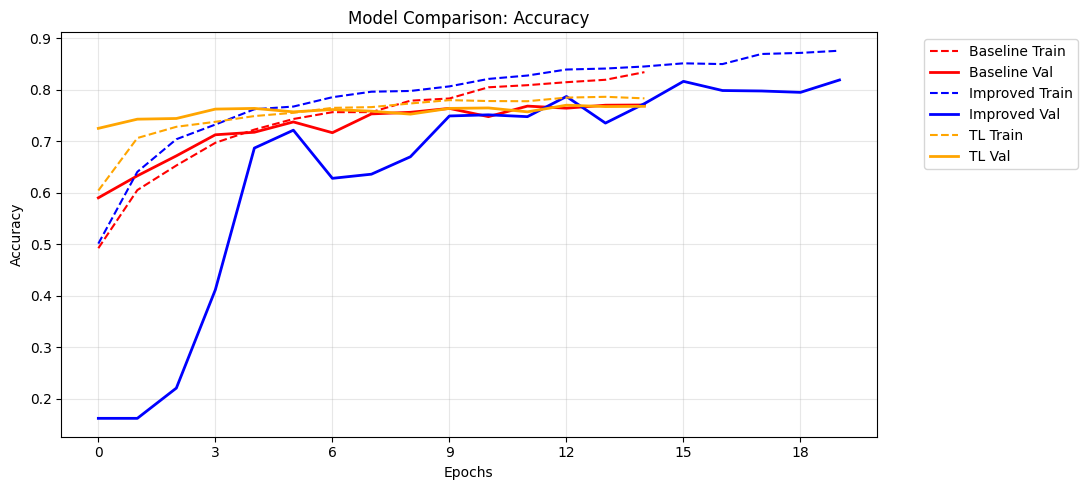

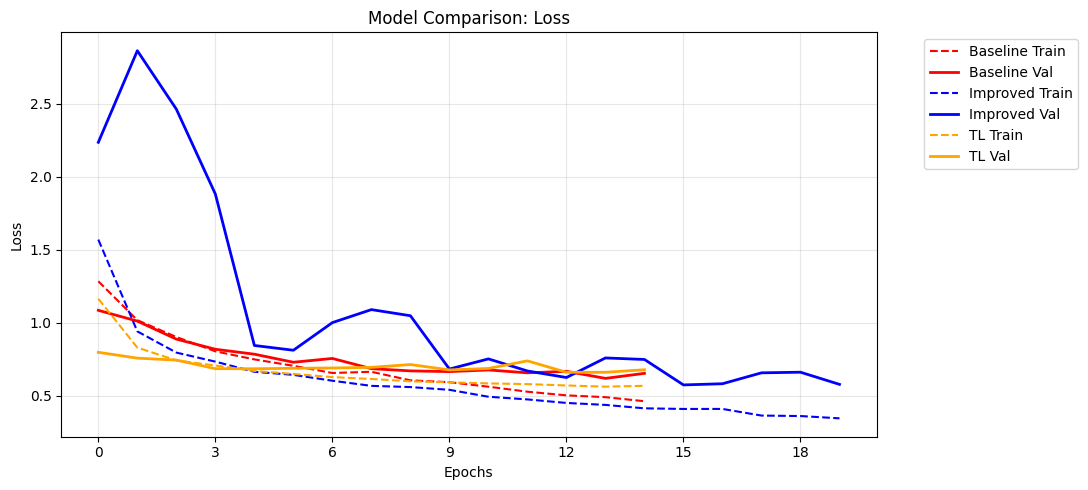

In [ ]:
# Accuracy
plt.figure(figsize=(11, 5))

plt.plot(history.history['accuracy'], label='Baseline Train', color='red', linestyle='--')
plt.plot(history.history['val_accuracy'], label='Baseline Val', color='red', linewidth=2)

plt.plot(history_improved.history['accuracy'], label='Improved Train', color='blue', linestyle='--')
plt.plot(history_improved.history['val_accuracy'], label='Improved Val', color='blue', linewidth=2)

plt.plot(history_tl.history['accuracy'], label='TL Train', color='orange', linestyle='--')
plt.plot(history_tl.history['val_accuracy'], label='TL Val', color='orange', linewidth=2)

plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.title('Model Comparison: Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))

# Loss
plt.plot(history.history['loss'], label='Baseline Train', color='red', linestyle='--')
plt.plot(history.history['val_loss'], label='Baseline Val', color='red', linewidth=2)

plt.plot(history_improved.history['loss'], label='Improved Train', color='blue', linestyle='--')
plt.plot(history_improved.history['val_loss'], label='Improved Val', color='blue', linewidth=2)

plt.plot(history_tl.history['loss'], label='TL Train', color='orange', linestyle='--')
plt.plot(history_tl.history['val_loss'], label='TL Val', color='orange', linewidth=2)

plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.title('Model Comparison: Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()